In [15]:
import numpy as np

data = np.load("px_0.0_Lx_12_MPI_results_h2.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var']


In [16]:
import numpy as np

data = np.load("px_0.0_Lx_12_MPI_results_h2.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
[ 0.03125  0.04     0.015    0.00375 -0.0275  -0.09125 -0.18625 -0.20125
 -0.3175  -0.40375 -0.4625  -0.5275  -0.5825  -0.65875 -0.6875  -0.73125
 -0.80375 -0.79625 -0.84125 -0.89375 -0.9    ]
[0.01002334 0.00990569 0.0135766  0.01352863 0.01549128 0.01761511
 0.01817936 0.01891118 0.02014322 0.01964121 0.02035645 0.01910853
 0.01857548 0.01846074 0.0173257  0.01627069 0.01459662 0.01520556
 0.0132865  0.01132415 0.01132631]
[0.08027344 0.0784     0.147275   0.14623594 0.19174375 0.24792344
 0.26406094 0.28574844 0.32419375 0.30823594 0.33109375 0.29174375
 0.27569375 0.27229844 0.23984375 0.21152344 0.17023594 0.18473594
 0.14104844 0.10246094 0.1025    ]


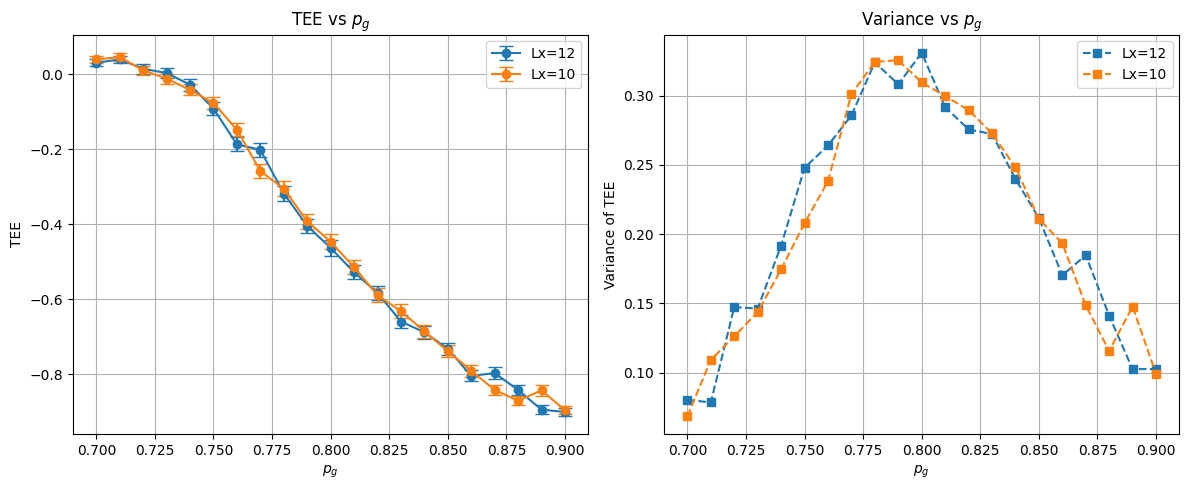

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import glob


cmap = plt.colormaps['gnuplot']
# npzファイルのパターン。Lxの値が変わる場合にマッチさせる
#files = glob.glob("Lx_*_MPI_results.npz")
files = glob.glob("px_0.0_Lx_*_MPI_results_h2.npz")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for file in files:
    data = np.load(file)
    # ファイル名からLxの値を抽出 (例: Lx_12_MPI_results.npz → 12)
    Lx_str = file.split("_")[3]  # '12'の部分
    Lx = int(Lx_str)
    #Lx_str = file.split("_")[1]  # '12'の部分
    #Lx = Lx_str

    pg = data['pg']
    TEE_ave = data['TEE_ave']
    TEE_err = data['TEE_err']
    TEE_var = data['TEE_var']

    data.close()

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err,fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)

ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('TEE')
ax[0].set_title('TEE vs $p_g$')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('$p_g$')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('Variance vs $p_g$')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig("px_0.0_MPI_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [48]:
Np=11
ps=0.5
for ip in range (Np):
    px=0.1
    pg=ps+(1-px-ps)*ip/(Np-1)
    print(pg)

0.5
0.54
0.58
0.62
0.66
0.7
0.74
0.78
0.8200000000000001
0.86
0.9
